In [4]:
#pip install pandas
#Referencia: Python for Data Science and Machine Learning Bootcamp - Udemy

## Pandas

In [1]:
# !uv add pandas matplotlib

In [2]:
import pandas as pd

In [3]:
%matplotlib inline

In [4]:
pd.__version__

'3.0.0'

### Carga de datos

In [10]:
# 1. Cargar y Limpiar Datos
peru_df = pd.read_csv('peru_df.csv')
peru_df

,cap,pob,departamento,area_km2,provincias,region,altitud_m,pib_per_capita
0,Chachapoyas,430,Amazonas,39249,7,Selva,2334,4200
1,Huaraz,1199,Áncash,35825,20,Sierra,3052,7600
2,Abancay,428,Apurímac,20895,7,Sierra,2378,5200
3,Arequipa,1580,Arequipa,63345,8,Costa,2335,8800
4,Ayacucho,670,Ayacucho,43890,11,Sierra,2761,4500
5,Cajamarca,1451,Cajamarca,33317,13,Sierra,2750,4800
6,Callao,1191,Provincia Constitucional del Callao,146,1,Costa,5,10500
7,Cusco,1390,Cusco,71873,13,Sierra,3399,7200
8,Huancavelica,343,Huancavelica,22131,7,Sierra,3676,3800
9,Huanuco,751,Huánuco,36887,11,Sierra,1890,4300


In [11]:
# Renombrar columnas para el reporte
peru_df.rename(columns={
    'cap': 'Capital',
    'pob': 'Población (millones)',
    'departamento': 'Departamento',
    'area_km2': 'Superficie (km²)',
    'provincias': 'Provincias',
    'region': 'Región',
    'altitud_m': 'Altitud (msnm)',
    'pib_per_capita': 'PIB per cápita'
}, inplace=True)

# Convertir miles a millones (asumiendo que los datos reales están en miles)
peru_df['Población (millones)'] = peru_df['Población (millones)'] / 1000

# Establecer el índice solicitado
peru_df.set_index('Departamento', inplace=True)

# 3. Mostrar Tabla
peru_df

,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita
Departamento,,,,,,,
Amazonas,Chachapoyas,0.430,39249,7,Selva,2334,4200
Áncash,Huaraz,1.199,35825,20,Sierra,3052,7600
Apurímac,Abancay,0.428,20895,7,Sierra,2378,5200
Arequipa,Arequipa,1.580,63345,8,Costa,2335,8800
Ayacucho,Ayacucho,0.670,43890,11,Sierra,2761,4500
Cajamarca,Cajamarca,1.451,33317,13,Sierra,2750,4800
Provincia Constitucional del Callao,Callao,1.191,146,1,Costa,5,10500
Cusco,Cusco,1.390,71873,13,Sierra,3399,7200
Huancavelica,Huancavelica,0.343,22131,7,Sierra,3676,3800


In [12]:
print(peru_df.info())
peru_df.sample(5)

<class 'pandas.DataFrame'>
Index: 25 entries, Amazonas to Ucayali
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Capital               25 non-null     str    
 1   Población (millones)  25 non-null     float64
 2   Superficie (km²)      25 non-null     int64  
 3   Provincias            25 non-null     int64  
 4   Región                25 non-null     str    
 5   Altitud (msnm)        25 non-null     int64  
 6   PIB per cápita        25 non-null     int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 1.6+ KB
None


,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita
Departamento,,,,,,,
Cajamarca,Cajamarca,1.451,33317,13,Sierra,2750,4800
Apurímac,Abancay,0.428,20895,7,Sierra,2378,5200
Piura,Piura,2.127,35733,8,Costa,29,6200
Puno,Puno,1.218,71999,13,Sierra,3827,4200
Cusco,Cusco,1.390,71873,13,Sierra,3399,7200


In [13]:
peru_df.describe()

,Población (millones),Superficie (km²),Provincias,Altitud (msnm),PIB per cápita
count,25.00000,25.000000,25.000000,25.000000,25.000000
mean,1.34896,51438.360000,7.840000,1596.800000,6700.000000
std,2.11797,70655.265313,4.469154,1488.992445,2542.636427
min,0.19100,146.000000,1.000000,5.000000,3800.000000
25%,0.42800,21328.000000,4.000000,154.000000,4800.000000
50%,1.04100,35733.000000,8.000000,1410.000000,6200.000000
75%,1.37800,51842.000000,11.000000,2761.000000,7600.000000
max,11.14800,368852.000000,20.000000,4330.000000,14200.000000


### Operaciones con Dataframes

In [14]:
tres_columnas = peru_df[['Capital', 'Altitud (msnm)', 'Región']]
tres_columnas

,Capital,Altitud (msnm),Región
Departamento,,,
Amazonas,Chachapoyas,2334,Selva
Áncash,Huaraz,3052,Sierra
Apurímac,Abancay,2378,Sierra
Arequipa,Arequipa,2335,Costa
Ayacucho,Ayacucho,2761,Sierra
Cajamarca,Cajamarca,2750,Sierra
Provincia Constitucional del Callao,Callao,5,Costa
Cusco,Cusco,3399,Sierra
Huancavelica,Huancavelica,3676,Sierra


In [15]:
def segmentar_pib(valor):
    """
    Clasifica el departamento según su capacidad económica.
    """
    if valor > 9000:
        return 'Alto'
    elif 5000 <= valor <= 9000:
        return 'Medio'
    else:
        return 'Bajo'

# 2. Utilizamos .apply() para crear la nueva columna
# Esto aplica la función fila por fila a la columna 'PIB per cápita'
peru_df['Nivel Económico'] = peru_df['PIB per cápita'].apply(segmentar_pib)
peru_df

,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico
Departamento,,,,,,,,
Amazonas,Chachapoyas,0.430,39249,7,Selva,2334,4200,Bajo
Áncash,Huaraz,1.199,35825,20,Sierra,3052,7600,Medio
Apurímac,Abancay,0.428,20895,7,Sierra,2378,5200,Medio
Arequipa,Arequipa,1.580,63345,8,Costa,2335,8800,Medio
Ayacucho,Ayacucho,0.670,43890,11,Sierra,2761,4500,Bajo
Cajamarca,Cajamarca,1.451,33317,13,Sierra,2750,4800,Bajo
Provincia Constitucional del Callao,Callao,1.191,146,1,Costa,5,10500,Alto
Cusco,Cusco,1.390,71873,13,Sierra,3399,7200,Medio
Huancavelica,Huancavelica,0.343,22131,7,Sierra,3676,3800,Bajo


In [16]:
# Seleccionar filas por índice
filas_seleccionadas_por_indice = peru_df.loc[['Cusco', 'Arequipa', 'Lima'], ['Población (millones)', 'Región']]
filas_seleccionadas_por_indice

,Población (millones),Región
Departamento,,
Cusco,1.390,Sierra
Arequipa,1.580,Costa
Lima,11.148,Costa


In [17]:
# Seleccionar filas por posición
# (en este caso, las filas 0, 3 y 13, que corresponden a 'Amazonas', 'Arequipa' y 'Lima')
filas_seleccionadas_por_posicion = peru_df.iloc[[7, 3, 14], [1, 4]]
filas_seleccionadas_por_posicion

,Población (millones),Región
Departamento,,
Cusco,1.390,Sierra
Arequipa,1.580,Costa
Lima,11.148,Costa


In [18]:
# Filtrar departamentos con población mayor a 1000
filtro_poblacion = peru_df['Población (millones)'] < 0.5
peru_df_filtrado = peru_df[filtro_poblacion]
peru_df_filtrado

,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico
Departamento,,,,,,,,
Amazonas,Chachapoyas,0.430,39249,7,Selva,2334,4200,Bajo
Apurímac,Abancay,0.428,20895,7,Sierra,2378,5200,Medio
Huancavelica,Huancavelica,0.343,22131,7,Sierra,3676,3800,Bajo
Madre de Dios,Puerto Maldonado,0.191,85300,3,Selva,186,6800,Medio
Moquegua,Moquegua,0.199,15733,3,Costa,1410,11000,Alto
Pasco,Cerro de Pasco,0.267,25319,3,Sierra,4330,5800,Medio
Tacna,Tacna,0.390,16075,4,Costa,562,9000,Medio
Tumbes,Tumbes,0.263,4669,3,Costa,7,5300,Medio


In [19]:
# Filtrar departamentos de la región 'Sierra'
filtro_region_sierra = peru_df['Región'] == 'Sierra'
peru_df_sierra = peru_df[filtro_region_sierra]
peru_df_sierra

,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico
Departamento,,,,,,,,
Áncash,Huaraz,1.199,35825,20,Sierra,3052,7600,Medio
Apurímac,Abancay,0.428,20895,7,Sierra,2378,5200,Medio
Ayacucho,Ayacucho,0.670,43890,11,Sierra,2761,4500,Bajo
Cajamarca,Cajamarca,1.451,33317,13,Sierra,2750,4800,Bajo
Cusco,Cusco,1.390,71873,13,Sierra,3399,7200,Medio
Huancavelica,Huancavelica,0.343,22131,7,Sierra,3676,3800,Bajo
Huánuco,Huanuco,0.751,36887,11,Sierra,1890,4300,Bajo
Junín,Huancayo,1.378,44410,9,Sierra,3250,6500,Medio
Pasco,Cerro de Pasco,0.267,25319,3,Sierra,4330,5800,Medio


In [20]:
# Agrupar por región y calcular la suma de la población
resumen_por_region = peru_df.groupby(by=['Región', 'Nivel Económico'])['Población (millones)'].sum()
resumen_por_region

Región  Nivel Económico
Costa   Alto               13.579
        Medio               7.815
Selva   Bajo                1.057
        Medio               2.178
Sierra  Bajo                4.433
        Medio               4.662
Name: Población (millones), dtype: float64

In [21]:
# Ordenar el DataFrame por la columna 'pob' en orden descendente
peru_df_ordenado = peru_df.sort_values(by='Población (millones)', ascending=False)
peru_df_ordenado

,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico
Departamento,,,,,,,,
Lima,Lima,11.148,34801,10,Costa,154,14200,Alto
Piura,Piura,2.127,35733,8,Costa,29,6200,Medio
La Libertad,Trujillo,2.104,25699,12,Costa,34,7000,Medio
Arequipa,Arequipa,1.580,63345,8,Costa,2335,8800,Medio
Cajamarca,Cajamarca,1.451,33317,13,Sierra,2750,4800,Bajo
Cusco,Cusco,1.390,71873,13,Sierra,3399,7200,Medio
Junín,Huancayo,1.378,44410,9,Sierra,3250,6500,Medio
Lambayeque,Chiclayo,1.351,14231,3,Costa,27,6200,Medio
Puno,Puno,1.218,71999,13,Sierra,3827,4200,Bajo


In [22]:
# Crear la nueva columna de densidad (Habitantes por km2)
peru_df['Densidad (hab/km²)'] = (peru_df['Población (millones)'] * 1_000_000) / peru_df['Superficie (km²)']
peru_df

,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico,Densidad (hab/km²)
Departamento,,,,,,,,,
Amazonas,Chachapoyas,0.430,39249,7,Selva,2334,4200,Bajo,10.955693
Áncash,Huaraz,1.199,35825,20,Sierra,3052,7600,Medio,33.468248
Apurímac,Abancay,0.428,20895,7,Sierra,2378,5200,Medio,20.483369
Arequipa,Arequipa,1.580,63345,8,Costa,2335,8800,Medio,24.942774
Ayacucho,Ayacucho,0.670,43890,11,Sierra,2761,4500,Bajo,15.265436
Cajamarca,Cajamarca,1.451,33317,13,Sierra,2750,4800,Bajo,43.551340
Provincia Constitucional del Callao,Callao,1.191,146,1,Costa,5,10500,Alto,8157.534247
Cusco,Cusco,1.390,71873,13,Sierra,3399,7200,Medio,19.339669
Huancavelica,Huancavelica,0.343,22131,7,Sierra,3676,3800,Bajo,15.498622


In [23]:
# Ejemplos de funciones de agregación
peru_df[["Población (millones)", "PIB per cápita"]].agg(["min", "max", "mean"])

,Población (millones),PIB per cápita
min,0.19100,3800.0
max,11.14800,14200.0
mean,1.34896,6700.0


In [24]:
# Ejemplo de funciones de agregación pero  personalizadas
def promedio_con_constante(columna, k=1.2):
    # Multiplicamos cada elemento por k, y al resultado le sacamos el promedio
    return (columna * k).mean()

agg_personalizado = peru_df[["Población (millones)", "PIB per cápita"]].agg(promedio_con_constante, k=1.5)
agg_personalizado

Población (millones)        2.02344
PIB per cápita          10050.00000
dtype: float64

In [27]:
#!uv add openpyxl

In [28]:
# 1. Exportar a Excel (Requiere la librería 'openpyxl')
peru_df.to_excel("peru_df_final.xlsx", index=True)

# 2. Exportar a CSV (El estándar para intercambio de datos)
peru_df.to_csv("peru_df_final.csv", index=True, encoding='utf-8-sig')

# 3. Exportar a JSON (Ideal para desarrollo web o bases de datos NoSQL)
peru_df.to_json("peru_df_final.json", orient="records", indent=4)

# 4. Exportar a HTML (Para insertar la tabla directamente en una web)
peru_df.to_html("peru_df_final.html")

### Merges y Joins

In [29]:
# Creamos la tabla de proyectos
data_proyectos = {
    'Departamento': ['Arequipa', 'Lima', 'Cusco', 'Piura', 'Loreto', 'Extranjero'],
    'Inversion_Millones': [1500, 4200, 850, 600, 300, 5000],
    'Tipo_Proyecto': ['Minería', 'Transporte', 'Energía', 'Agricultura', 'Ambiental', 'Comercio'],
    'Estado': ['Ejecución', 'Planificación', 'Ejecución', 'Finalizado', 'Suspendido', 'Nuevo']
}

proyectos_df = pd.DataFrame(data_proyectos)
proyectos_df

,Departamento,Inversion_Millones,Tipo_Proyecto,Estado
0,Arequipa,1500,Minería,Ejecución
1,Lima,4200,Transporte,Planificación
2,Cusco,850,Energía,Ejecución
3,Piura,600,Agricultura,Finalizado
4,Loreto,300,Ambiental,Suspendido
5,Extranjero,5000,Comercio,Nuevo


In [30]:
# Solo quedarán: Arequipa, Lima, Cusco, Piura, Loreto
inner_df = pd.merge(peru_df, proyectos_df, on='Departamento', how='inner')
inner_df

,Departamento,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico,Densidad (hab/km²),Inversion_Millones,Tipo_Proyecto,Estado
0,Arequipa,Arequipa,1.580,63345,8,Costa,2335,8800,Medio,24.942774,1500,Minería,Ejecución
1,Cusco,Cusco,1.390,71873,13,Sierra,3399,7200,Medio,19.339669,850,Energía,Ejecución
2,Lima,Lima,11.148,34801,10,Costa,154,14200,Alto,320.335623,4200,Transporte,Planificación
3,Loreto,Iquitos,1.052,368852,8,Selva,104,5400,Medio,2.852092,300,Ambiental,Suspendido
4,Piura,Piura,2.127,35733,8,Costa,29,6200,Medio,59.524809,600,Agricultura,Finalizado


In [32]:
# Es el más usado para reportes generales.
left_df = pd.merge(peru_df, proyectos_df, on='Departamento', how='left')
left_df

,Departamento,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico,Densidad (hab/km²),Inversion_Millones,Tipo_Proyecto,Estado
0,Amazonas,Chachapoyas,0.430,39249,7,Selva,2334,4200,Bajo,10.955693,NaN,NaN,NaN
1,Áncash,Huaraz,1.199,35825,20,Sierra,3052,7600,Medio,33.468248,NaN,NaN,NaN
2,Apurímac,Abancay,0.428,20895,7,Sierra,2378,5200,Medio,20.483369,NaN,NaN,NaN
3,Arequipa,Arequipa,1.580,63345,8,Costa,2335,8800,Medio,24.942774,1500.0,Minería,Ejecución
4,Ayacucho,Ayacucho,0.670,43890,11,Sierra,2761,4500,Bajo,15.265436,NaN,NaN,NaN
5,Cajamarca,Cajamarca,1.451,33317,13,Sierra,2750,4800,Bajo,43.551340,NaN,NaN,NaN
6,Provincia Constitucional del Callao,Callao,1.191,146,1,Costa,5,10500,Alto,8157.534247,NaN,NaN,NaN
7,Cusco,Cusco,1.390,71873,13,Sierra,3399,7200,Medio,19.339669,850.0,Energía,Ejecución
8,Huancavelica,Huancavelica,0.343,22131,7,Sierra,3676,3800,Bajo,15.498622,NaN,NaN,NaN
9,Huánuco,Huanuco,0.751,36887,11,Sierra,1890,4300,Bajo,20.359476,NaN,NaN,NaN


In [33]:
# Verán que aparece la fila 'Extranjero' pero sin datos de población o superficie.
right_df = pd.merge(peru_df, proyectos_df, on='Departamento', how='right')
right_df

,Departamento,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico,Densidad (hab/km²),Inversion_Millones,Tipo_Proyecto,Estado
0,Arequipa,Arequipa,1.580,63345.0,8.0,Costa,2335.0,8800.0,Medio,24.942774,1500,Minería,Ejecución
1,Lima,Lima,11.148,34801.0,10.0,Costa,154.0,14200.0,Alto,320.335623,4200,Transporte,Planificación
2,Cusco,Cusco,1.390,71873.0,13.0,Sierra,3399.0,7200.0,Medio,19.339669,850,Energía,Ejecución
3,Piura,Piura,2.127,35733.0,8.0,Costa,29.0,6200.0,Medio,59.524809,600,Agricultura,Finalizado
4,Loreto,Iquitos,1.052,368852.0,8.0,Selva,104.0,5400.0,Medio,2.852092,300,Ambiental,Suspendido
5,Extranjero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000,Comercio,Nuevo


In [34]:
outer_df = pd.merge(peru_df, proyectos_df, on='Departamento', how='outer')
outer_df

,Departamento,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico,Densidad (hab/km²),Inversion_Millones,Tipo_Proyecto,Estado
0,Amazonas,Chachapoyas,0.430,39249.0,7.0,Selva,2334.0,4200.0,Bajo,10.955693,NaN,NaN,NaN
1,Apurímac,Abancay,0.428,20895.0,7.0,Sierra,2378.0,5200.0,Medio,20.483369,NaN,NaN,NaN
2,Arequipa,Arequipa,1.580,63345.0,8.0,Costa,2335.0,8800.0,Medio,24.942774,1500.0,Minería,Ejecución
3,Ayacucho,Ayacucho,0.670,43890.0,11.0,Sierra,2761.0,4500.0,Bajo,15.265436,NaN,NaN,NaN
4,Cajamarca,Cajamarca,1.451,33317.0,13.0,Sierra,2750.0,4800.0,Bajo,43.551340,NaN,NaN,NaN
5,Cusco,Cusco,1.390,71873.0,13.0,Sierra,3399.0,7200.0,Medio,19.339669,850.0,Energía,Ejecución
6,Extranjero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.0,Comercio,Nuevo
7,Huancavelica,Huancavelica,0.343,22131.0,7.0,Sierra,3676.0,3800.0,Bajo,15.498622,NaN,NaN,NaN
8,Huánuco,Huanuco,0.751,36887.0,11.0,Sierra,1890.0,4300.0,Bajo,20.359476,NaN,NaN,NaN
9,Ica,Ica,1.041,21328.0,5.0,Costa,406.0,9200.0,Alto,48.809077,NaN,NaN,NaN


In [35]:
data_encargados = {
    'Responsable': ['Ing. García', 'Dra. López', 'Ing. Torres', 'Lic. Ruiz', 'Ing. Salas', 'Eco. Benites'],
    'Fecha_Inicio': ['2024-01', '2023-11', '2024-03', '2023-06', '2024-05', '2024-08']
}
encargados_df = pd.DataFrame(data_encargados)
encargados_df

,Responsable,Fecha_Inicio
0,Ing. García,2024-01
1,Dra. López,2023-11
2,Ing. Torres,2024-03
3,Lic. Ruiz,2023-06
4,Ing. Salas,2024-05
5,Eco. Benites,2024-08


In [36]:
# Pegamos por la derecha usando axis=1
proyectos_extendido = pd.concat([proyectos_df, encargados_df], axis=1)
proyectos_extendido

,Departamento,Inversion_Millones,Tipo_Proyecto,Estado,Responsable,Fecha_Inicio
0,Arequipa,1500,Minería,Ejecución,Ing. García,2024-01
1,Lima,4200,Transporte,Planificación,Dra. López,2023-11
2,Cusco,850,Energía,Ejecución,Ing. Torres,2024-03
3,Piura,600,Agricultura,Finalizado,Lic. Ruiz,2023-06
4,Loreto,300,Ambiental,Suspendido,Ing. Salas,2024-05
5,Extranjero,5000,Comercio,Nuevo,Eco. Benites,2024-08


In [37]:
data_nuevos_proyectos = {
    'Departamento': ['Tacna', 'Puno'],
    'Inversion_Millones': [450, 920],
    'Tipo_Proyecto': ['Salud', 'Minería'],
    'Estado': ['Planificación', 'Ejecución']
}
nuevos_proyectos_df = pd.DataFrame(data_nuevos_proyectos)
nuevos_proyectos_df

,Departamento,Inversion_Millones,Tipo_Proyecto,Estado
0,Tacna,450,Salud,Planificación
1,Puno,920,Minería,Ejecución


In [38]:
# Pegamos por abajo (axis=0 es el valor por defecto)
proyectos_final = pd.concat([proyectos_df, nuevos_proyectos_df], axis=0).reset_index(drop=True)
proyectos_final

,Departamento,Inversion_Millones,Tipo_Proyecto,Estado
0,Arequipa,1500,Minería,Ejecución
1,Lima,4200,Transporte,Planificación
2,Cusco,850,Energía,Ejecución
3,Piura,600,Agricultura,Finalizado
4,Loreto,300,Ambiental,Suspendido
5,Extranjero,5000,Comercio,Nuevo
6,Tacna,450,Salud,Planificación
7,Puno,920,Minería,Ejecución


### Visualización

<Axes: xlabel='Departamento'>

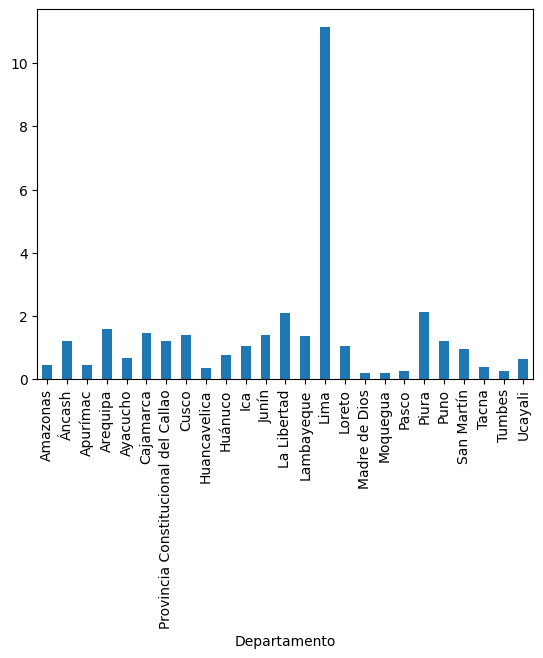

In [48]:
# crear histograma a partir del df - si hay seaborn lo toma como base
peru_df['Población (millones)'].plot(
    kind='bar', 
    # figsize=(12, 5), 
    # color='darkblue', 
    # title='Población por Departamento (en millones)',
    # ylabel='Millones de Habitantes',
    # xlabel='Departamentos'
)

<Axes: ylabel='Frequency'>

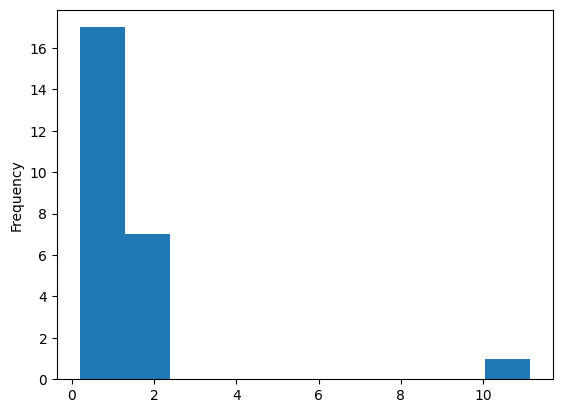

In [49]:
# Esto NO muestra los nombres abajo, muestra cuántos departamentos hay por rango de población
peru_df['Población (millones)'].plot(
    kind='hist', 
    # bins=8,                # Dividimos el rango en 8 contenedores
    # figsize=(12, 5), 
    # color='darkblue',      # Mantenemos tu color corporativo
    # edgecolor='white',     # Línea blanca para separar las barras
    # title='Distribución de la Población Departamental',
    # grid=True
)

<Axes: xlabel='Departamento'>

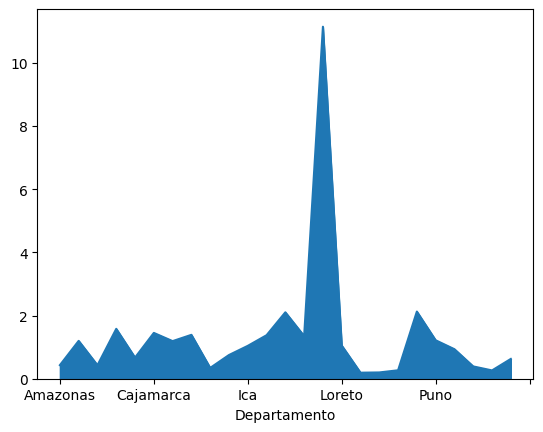

In [47]:
#area
peru_df['Población (millones)'].plot(
    kind='area', 
    # stacked=False, 
    # figsize=(12, 5), 
    # alpha=0.5, # Transparencia para que se vea la rejilla
    # title='Área de Población por Departamento',
    # color='darkcyan'
)

<Axes: title={'center': 'Comparación Lado a Lado (Stacked=False)'}, xlabel='Departamento'>

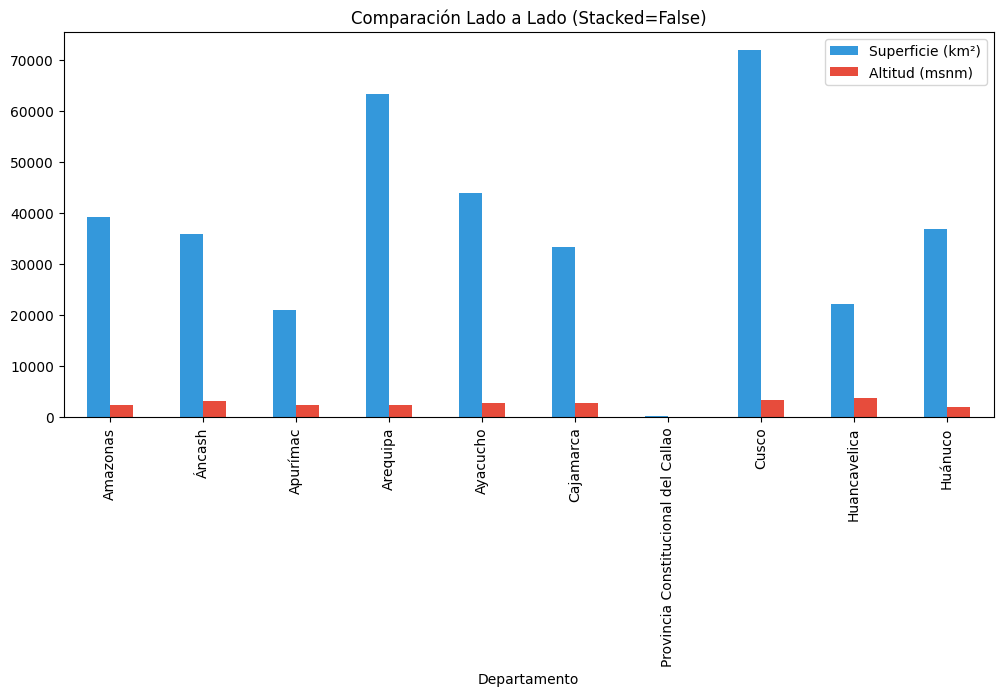

In [54]:
#barra - haciendo recorte de filas
peru_df[['Superficie (km²)', 'Altitud (msnm)']].head(10).plot(
    kind='bar', 
    stacked=False, 
    figsize=(12, 5),
    color=['#3498db', '#e74c3c'], # Azul y Rojo
    title='Comparación Lado a Lado (Stacked=False)'
)

<Axes: title={'center': 'Comparación Lado a Lado (Stacked=False)'}, xlabel='Departamento'>

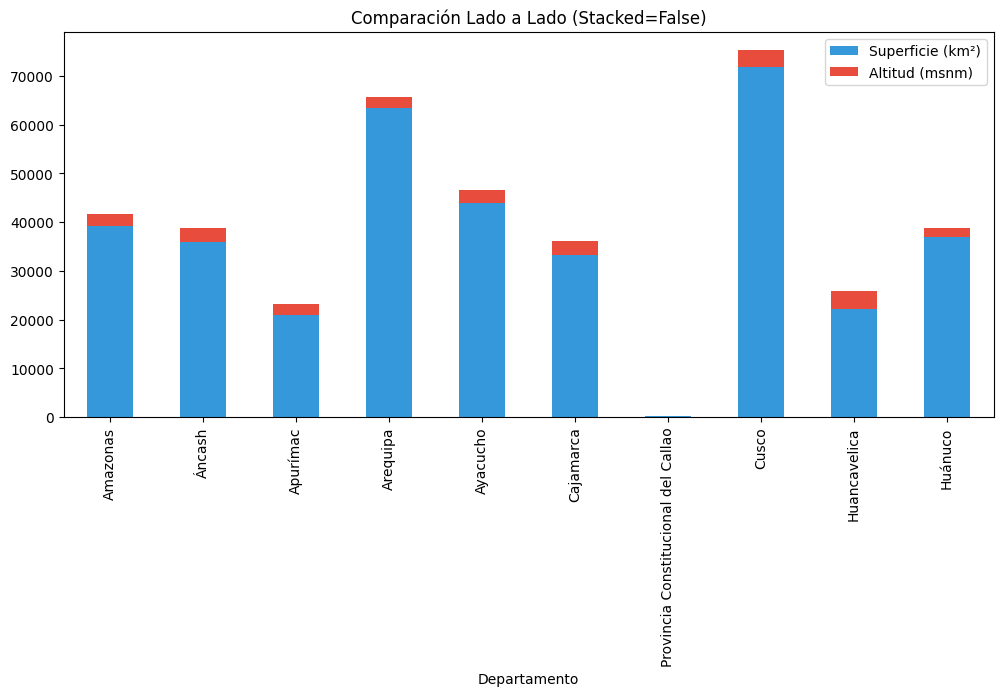

In [56]:
#barra apilada - haciendo recorte de filas
peru_df[['Superficie (km²)', 'Altitud (msnm)']].head(10).plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 5),
    color=['#3498db', '#e74c3c'], # Azul y Rojo
    title='Comparación Lado a Lado (Stacked=False)'
)

<Axes: xlabel='Departamento'>

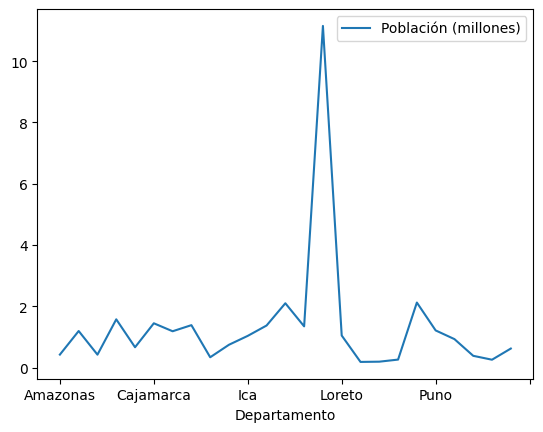

In [59]:
#series de tiempo
peru_df[['Población (millones)']].plot(
    kind='line', 
    # figsize=(12, 5), 
    # marker='o',          # Añade puntos en cada departamento
    # linewidth=2,         # Grosor de la línea
    # grid=True,           # Rejilla para facilitar la lectura
    # title='Tendencia de Población vs PIB por Departamento'
)

<Axes: xlabel='Población (millones)', ylabel='PIB per cápita'>

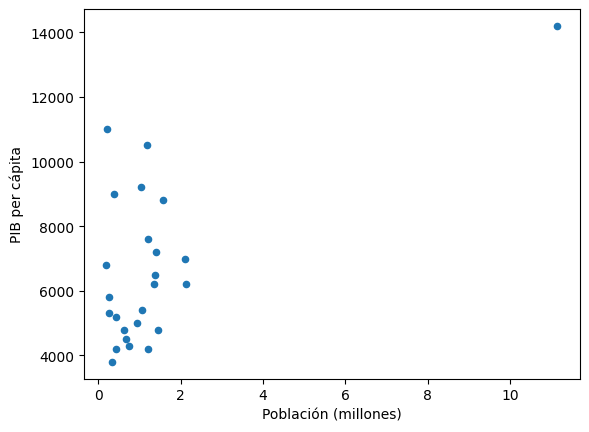

In [61]:
#scatter
peru_df.plot(
    kind='scatter', 
    x='Población (millones)', 
    y='PIB per cápita', 
    # figsize=(10, 6), 
    # color='darkred', 
    # s=100,          # Tamaño de los puntos
    # alpha=0.6,      # Transparencia para ver puntos solapados
    # title='Relación entre Población y PIB per cápita',
    # grid=True
)

<Axes: title={'center': 'Distribución General de la Población'}>

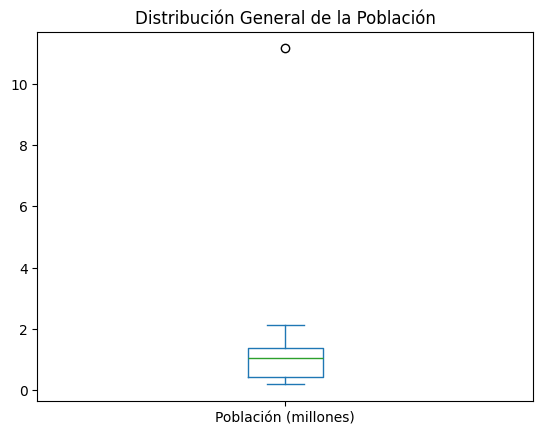

In [63]:
#boxplot
peru_df['Población (millones)'].plot(kind='box', title='Distribución General de la Población')

### Practica
1. Generación de Datos: Crear un DataFrame de Pandas donde la columna RADIO contenga una secuencia numérica del 1 al 20 usando range().
2. Cálculo de Área: Crear la columna AREA aplicando la fórmula del área de un círculo ($\pi \cdot r^2$) utilizando cada valor de la columna RADIO.
3. Cálculo de Volumen: Crear la columna VOLUMEN aplicando la fórmula del volumen de una esfera ($\frac{4}{3} \cdot \pi \cdot r^3$). Reto: Para practicar la lógica de datos, extrae el radio a partir de la columna AREA calculada anteriormente ($r = \sqrt{Area/\pi}$).

1. **Función de Área**: 
   $f(r) = \pi r^2$
   
2. **Función de Volumen**: 
   $g(r) = \frac{4}{3} \pi r^3$

In [64]:
import pandas as pd
import numpy as np

# Función para el Área
def calcular_area(radio):
    return np.pi * (radio**2)

# Función para el Volumen
def calcular_volumen(radio):
    return (4/3) * np.pi * (radio**3)

    
# Crear el DataFrame inicial
df_geo = pd.DataFrame({'RADIO': range(1, 21)})

# Aplicar las funciones usando .apply()
df_geo['AREA'] = df_geo['RADIO'].apply(calcular_area)

# Para el volumen, también usamos el RADIO original
df_geo['VOLUMEN'] = df_geo['RADIO'].apply(calcular_volumen)

df_geo

,RADIO,AREA,VOLUMEN
0,1,3.141593,4.188790
1,2,12.566371,33.510322
2,3,28.274334,113.097336
3,4,50.265482,268.082573
4,5,78.539816,523.598776
5,6,113.097336,904.778684
6,7,153.938040,1436.755040
7,8,201.061930,2144.660585
8,9,254.469005,3053.628059
9,10,314.159265,4188.790205


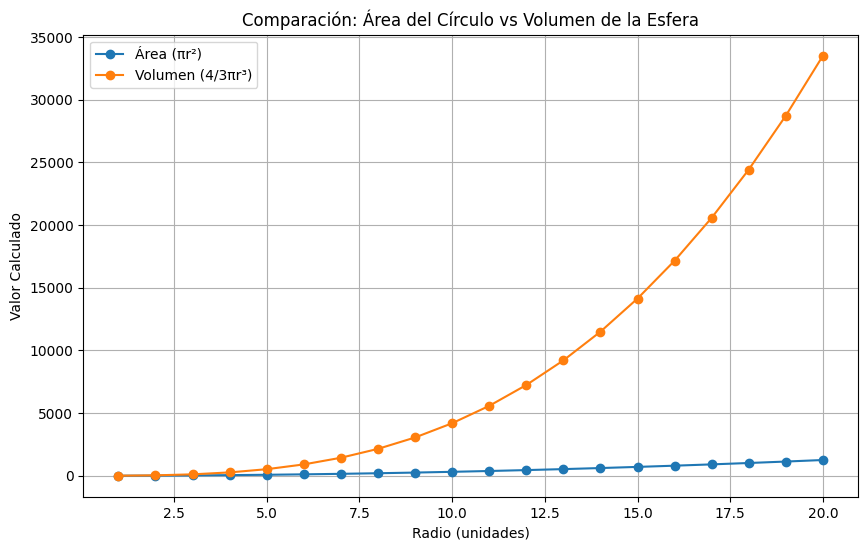

In [65]:
import matplotlib.pyplot as plt

# Usamos el método .plot() de Pandas directamente
# x='RADIO' define el eje horizontal
# y=['AREA', 'VOLUMEN'] define las dos líneas que queremos ver
ax = df_geo.plot(x='RADIO', 
                 y=['AREA', 'VOLUMEN'], 
                 kind='line', 
                 marker='o', 
                 figsize=(10, 6),
                 grid=True)

# Personalización adicional
plt.title('Comparación: Área del Círculo vs Volumen de la Esfera')
plt.xlabel('Radio (unidades)')
plt.ylabel('Valor Calculado')
plt.legend(['Área (πr²)', 'Volumen (4/3πr³)'])

plt.show()